In [2]:
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl'])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl'], returncode=0)

In [5]:
# Importing all the tools we need
import pandas as pd              # for data manipulation
import numpy as np               # for numbers/math
import matplotlib.pyplot as plt  # for charts
import seaborn as sns            # for better-looking charts
import datetime as dt            # for date calculations
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [16]:
import pandas as pd
import os

# Confirm you're in the right folder
print("Folder:", os.getcwd())
print("Files:", os.listdir())

# Load the CSV file
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

# Confirm it loaded
print("Success! Shape:", df.shape)
print(df.head())

Folder: c:\Users\roys1\OneDrive\Desktop\customer_segmention
Files: ['.vscode', 'desktop.ini', 'OnlineRetail.csv']
Success! Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [17]:
# How many rows and columns?
print("Shape:", df.shape)

# Column names and data types
print(df.info())

# Basic statistics
df.describe()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [18]:
# Count missing values in each column
print(df.isnull().sum())

# Percentage of missing values
print(df.isnull().sum() / len(df) * 100)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [19]:
# We can't do customer analysis without CustomerID
# So we drop those rows

print("Before cleaning:", df.shape)

df.dropna(subset=['CustomerID'], inplace=True)

print("After removing missing CustomerID:", df.shape)

Before cleaning: (541909, 8)
After removing missing CustomerID: (406829, 8)


In [20]:
# Cancelled orders start with 'C' in InvoiceNo
# Example: C536379 = cancelled order

# Check how many cancelled orders exist
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print("Cancelled orders:", len(cancelled))

# Remove them
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancelled orders:", df.shape)

Cancelled orders: 8905
After removing cancelled orders: (397924, 8)


In [21]:
# Negative quantity = returned items, not real purchases
print("Rows with Quantity <= 0:", len(df[df['Quantity'] <= 0]))

df = df[df['Quantity'] > 0]

# Also remove rows where UnitPrice is 0 or negative
df = df[df['UnitPrice'] > 0]

print("Final clean shape:", df.shape)

Rows with Quantity <= 0: 0
Final clean shape: (397884, 8)


In [22]:
# Make sure CustomerID is treated as a string (not a number)
df['CustomerID'] = df['CustomerID'].astype(str)

# Make sure InvoiceDate is datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Confirm changes
print(df.dtypes)

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object


In [23]:
# Revenue = Quantity × UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Check the new column
print(df[['Quantity', 'UnitPrice', 'Revenue']].head(10))

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34
5         2       7.65    15.30
6         6       4.25    25.50
7         6       1.85    11.10
8         6       1.85    11.10
9        32       1.69    54.08


In [24]:
print("Total Customers:", df['CustomerID'].nunique())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Revenue: £", round(df['Revenue'].sum(), 2))
print("Date Range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Total Customers: 4338
Total Orders: 18532
Total Revenue: £ 8911407.9
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [25]:
# Snapshot date = 1 day after the last purchase in dataset
# This is our "today" for calculating recency

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [26]:
# Recency = how many days since last purchase
# Lower number = more recent = better

recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df.columns = ['CustomerID', 'LastPurchaseDate']
recency_df['Recency'] = (snapshot_date - recency_df['LastPurchaseDate']).dt.days

print(recency_df.head())

  CustomerID    LastPurchaseDate  Recency
0    12346.0 2011-01-18 10:01:00      326
1    12347.0 2011-12-07 15:52:00        2
2    12348.0 2011-09-25 13:13:00       75
3    12349.0 2011-11-21 09:51:00       19
4    12350.0 2011-02-02 16:01:00      310


In [27]:
# Frequency = total number of unique orders
# Higher = better

frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.columns = ['CustomerID', 'Frequency']

print(frequency_df.head())

  CustomerID  Frequency
0    12346.0          1
1    12347.0          7
2    12348.0          4
3    12349.0          1
4    12350.0          1


In [28]:
# Monetary = total money spent by each customer
# Higher = better

monetary_df = df.groupby('CustomerID')['Revenue'].sum().reset_index()
monetary_df.columns = ['CustomerID', 'Monetary']

print(monetary_df.head())

  CustomerID  Monetary
0    12346.0  77183.60
1    12347.0   4310.00
2    12348.0   1797.24
3    12349.0   1757.55
4    12350.0    334.40


In [29]:
# Merge all three into one table
rfm = recency_df[['CustomerID', 'Recency']].merge(frequency_df, on='CustomerID')
rfm = rfm.merge(monetary_df, on='CustomerID')

print(rfm.head(10))
print("\nRFM Table Shape:", rfm.shape)
print("\nBasic Stats:")
print(rfm.describe())

  CustomerID  Recency  Frequency  Monetary
0    12346.0      326          1  77183.60
1    12347.0        2          7   4310.00
2    12348.0       75          4   1797.24
3    12349.0       19          1   1757.55
4    12350.0      310          1    334.40
5    12352.0       36          8   2506.04
6    12353.0      204          1     89.00
7    12354.0      232          1   1079.40
8    12355.0      214          1    459.40
9    12356.0       23          3   2811.43

RFM Table Shape: (4338, 4)

Basic Stats:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


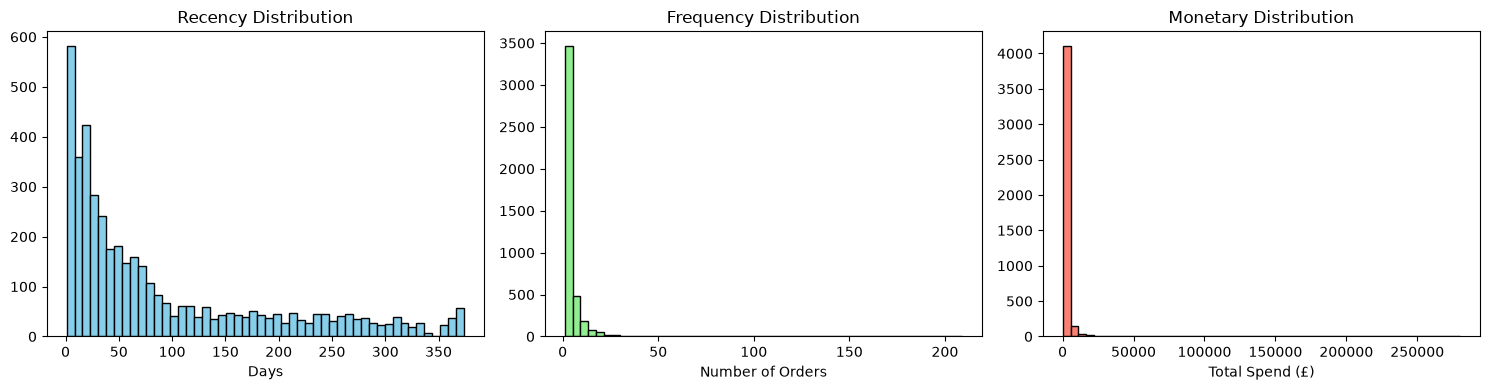

In [30]:
# Plot distribution of each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')

axes[2].hist(rfm['Monetary'], bins=50, color='salmon', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (£)')

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150)
plt.show()

In [31]:
# Problem: Recency is in days (0-700), Monetary is in pounds (0-200,000)
# K-Means gets confused by different scales
# Solution: Standardize everything to same scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Convert to DataFrame for easy viewing
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print(rfm_scaled_df.describe())
# Now mean ≈ 0 and std ≈ 1 for all columns

            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean   2.702618e-17  1.801745e-17  1.801745e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.153401e-01 -4.250965e-01 -2.281344e-01
25%   -7.453445e-01 -4.250965e-01 -1.943495e-01
50%   -4.153533e-01 -2.951776e-01 -1.535104e-01
75%    4.946227e-01  9.457903e-02 -4.367134e-02
max    2.814561e+00  2.659803e+01  3.094634e+01


k=1, Inertia=13014.00
k=2, Inertia=9012.64
k=3, Inertia=5439.30
k=4, Inertia=4092.14
k=5, Inertia=3118.28
k=6, Inertia=2472.57
k=7, Inertia=2022.41
k=8, Inertia=1742.37
k=9, Inertia=1445.63
k=10, Inertia=1303.39


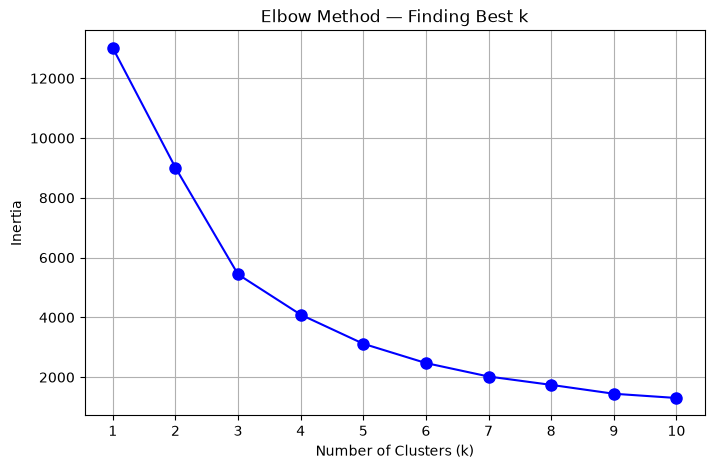

Look for the 'elbow' — where the curve bends sharply. That's your best k.


In [32]:
from sklearn.cluster import KMeans

# Try k from 1 to 10 and record the inertia (error)
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    print(f"k={k}, Inertia={km.inertia_:.2f}")

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

print("Look for the 'elbow' — where the curve bends sharply. That's your best k.")

In [33]:
# Apply K-Means with 4 clusters
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Check how many customers in each cluster
print(rfm['Cluster'].value_counts())

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


In [34]:
# Average RFM values per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_summary)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


In [35]:
# Add labels based on your cluster numbers (adjust 0,1,2,3 based on YOUR results)
cluster_labels = {
    0: 'Champions',
    1: 'At Risk',
    2: 'Lost Customers',
    3: 'New Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

Segment
Champions         3054
At Risk           1067
New Customers      204
Lost Customers      13
Name: count, dtype: int64


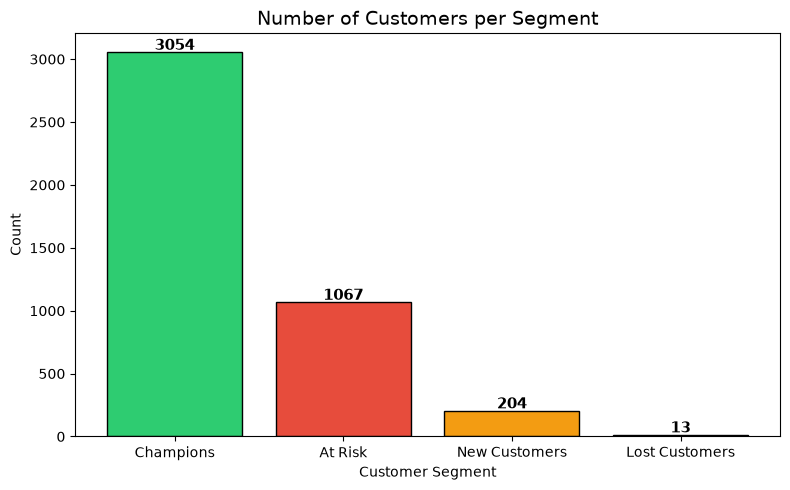

In [36]:
plt.figure(figsize=(8, 5))
segment_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']

bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black')

# Add count labels on top of bars
for bar, count in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontsize=11, fontweight='bold')

plt.title('Number of Customers per Segment', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('segment_counts.png', dpi=150)
plt.show()

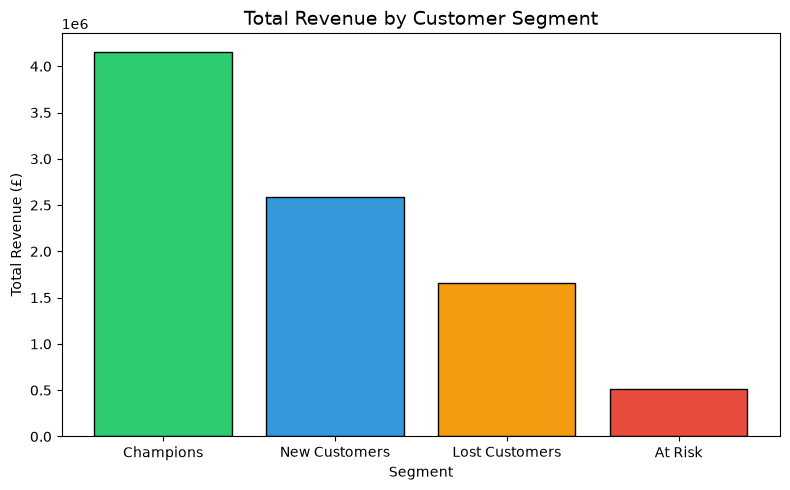

In [37]:
plt.figure(figsize=(8, 5))
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.bar(revenue_by_segment.index, revenue_by_segment.values,
        color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'], edgecolor='black')

plt.title('Total Revenue by Customer Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=150)
plt.show()

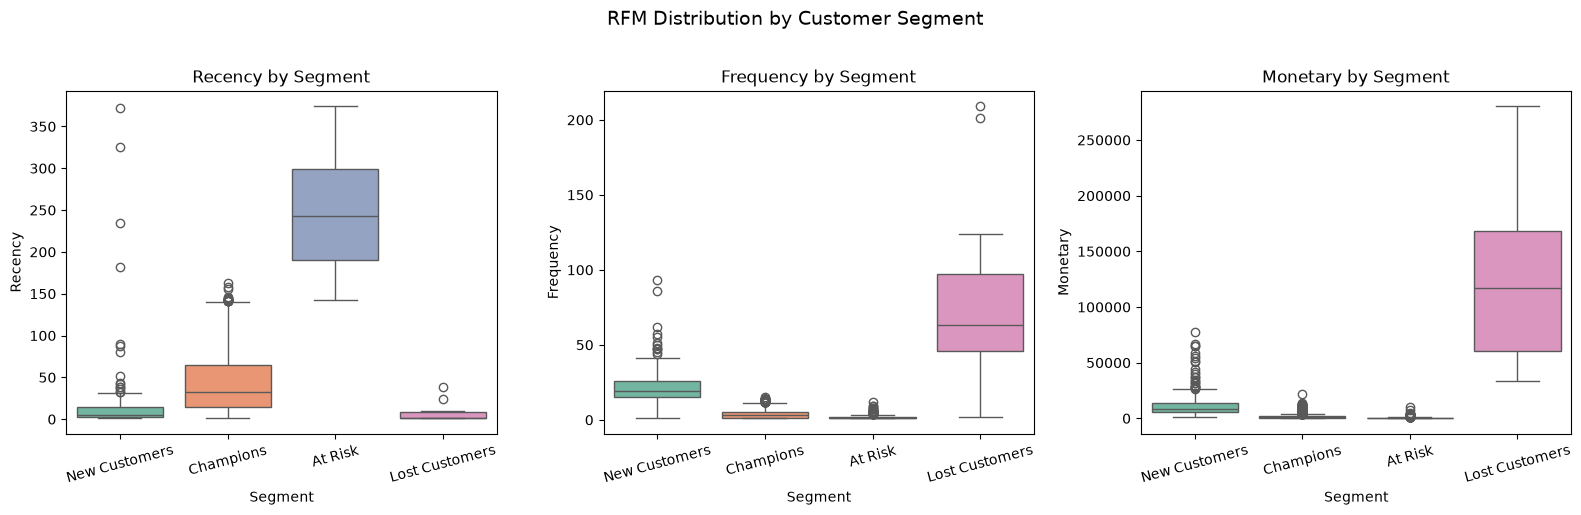

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Segment', y='Recency', data=rfm, ax=axes[0], palette='Set2')
axes[0].set_title('Recency by Segment')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment', y='Frequency', data=rfm, ax=axes[1], palette='Set2')
axes[1].set_title('Frequency by Segment')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment', y='Monetary', data=rfm, ax=axes[2], palette='Set2')
axes[2].set_title('Monetary by Segment')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('RFM Distribution by Customer Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=150)
plt.show()

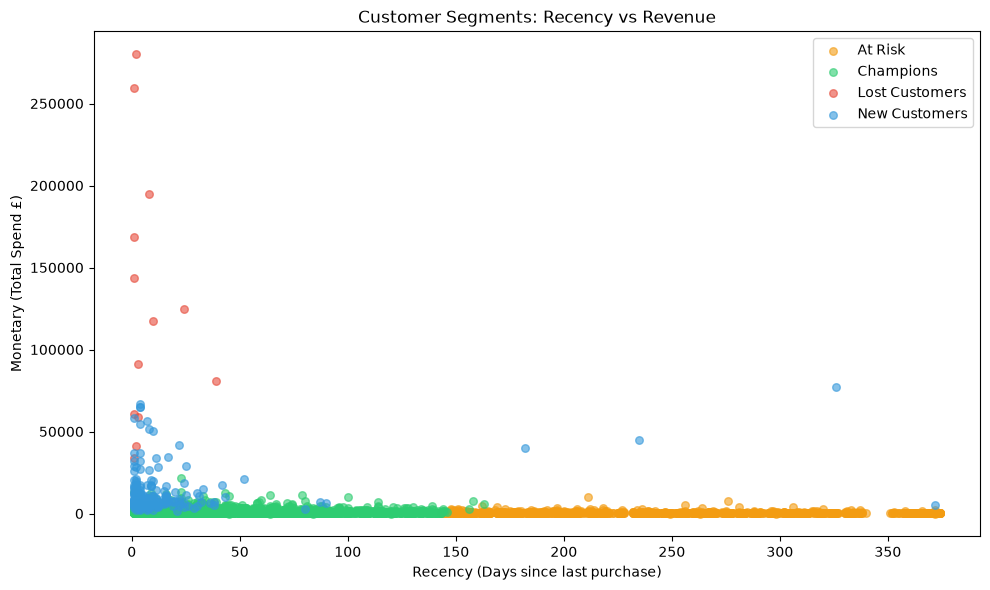

In [39]:
plt.figure(figsize=(10, 6))
colors_map = {'Champions': '#2ecc71', 'At Risk': '#f39c12',
              'Lost Customers': '#e74c3c', 'New Customers': '#3498db'}

for segment, group in rfm.groupby('Segment'):
    plt.scatter(group['Recency'], group['Monetary'],
                label=segment, alpha=0.6, s=30, color=colors_map[segment])

plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spend £)')
plt.title('Customer Segments: Recency vs Revenue')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_segments.png', dpi=150)
plt.show()

In [40]:
final_summary = rfm.groupby('Segment').agg(
    Total_Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)

print("=" * 60)
print("FINAL CUSTOMER SEGMENTATION SUMMARY")
print("=" * 60)
print(final_summary)

FINAL CUSTOMER SEGMENTATION SUMMARY
                Total_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                     
At Risk                    1067       248.08           1.55        480.62   
Champions                  3054        43.70           3.68       1359.05   
Lost Customers               13         7.38          82.54     127338.31   
New Customers               204        15.50          22.33      12709.09   

                Total_Revenue  
Segment                        
At Risk             512818.85  
Champions          4150536.51  
Lost Customers     1655398.08  
New Customers      2592654.46  
